In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_excel("rajasthan_mustard_clean.xlsx")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nBasic Info:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (25000, 19)

Columns: ['District', 'Crop', 'Season', 'Area (hectares)', 'Yield (quintals)', 'Production (metric tons)', 'Soil Type', 'pH Level', 'Organic Matter (%)', 'Nitrogen Content (kg/ha)', 'Phosphorus Content (kg/ha)', 'Potassium Content (kg/ha)', 'Irrigation Method', 'Water Consumption (liters/hectare)', 'Water Availability (liters/hectare)', 'temp', 'rain', 'humidity', 'wind_speed']

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   District                             25000 non-null  object 
 1   Crop                                 25000 non-null  object 
 2   Season                               25000 non-null  object 
 3   Area (hectares)                      25000 non-null  float64
 4   Yield (quintals)                     25000 non-null  float64
 5   Pr

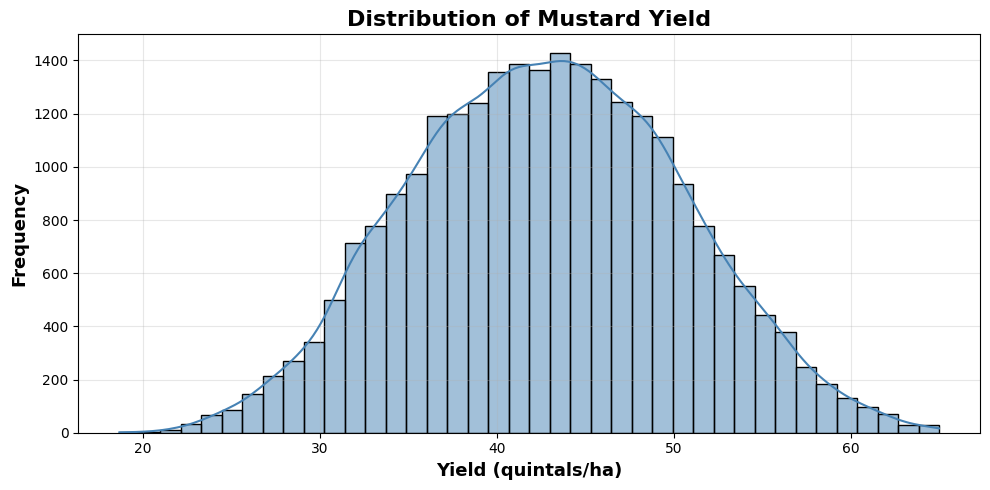

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Yield (quintals)'], bins=40, kde=True, color='steelblue')
plt.xlabel('Yield (quintals/ha)', fontsize=13, fontweight='bold')
plt.ylabel('Frequency', fontsize=13, fontweight='bold')
plt.title('Distribution of Mustard Yield', fontsize=16, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

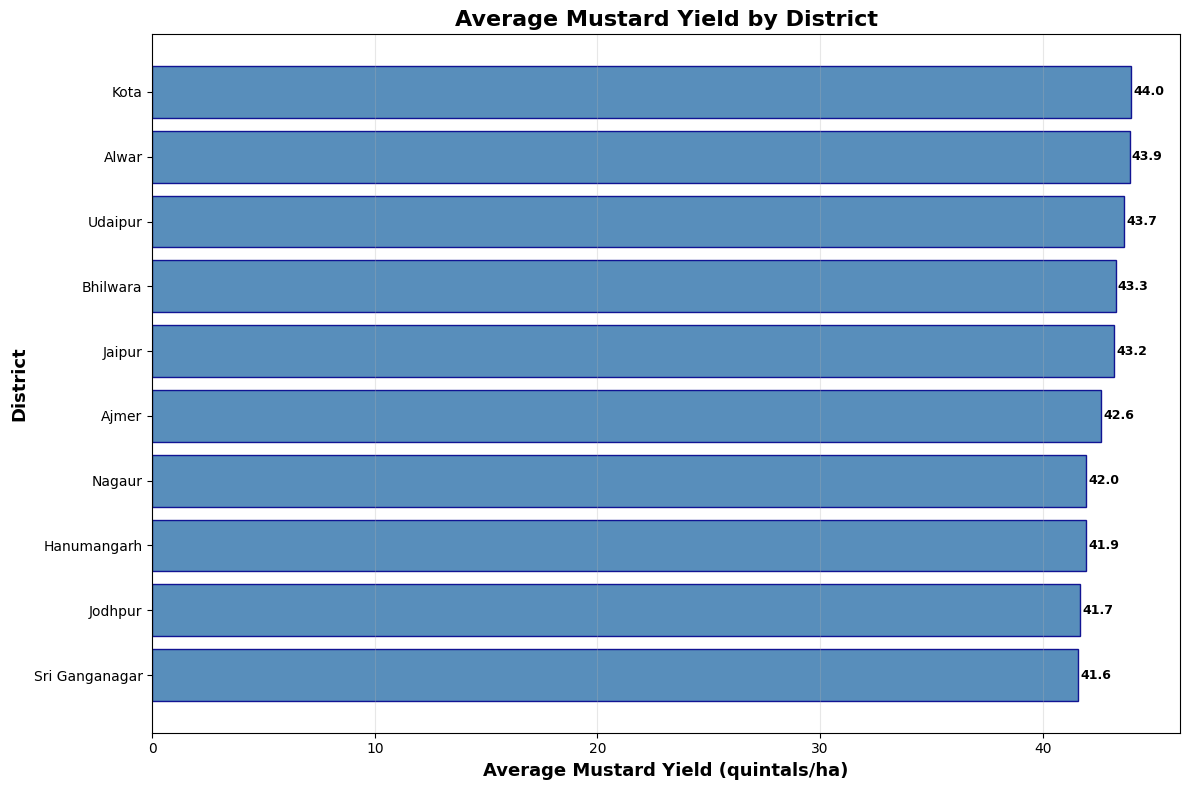

In [8]:
plt.figure(figsize=(12, 8))
district_yield = df.groupby('District')['Yield (quintals)'].mean().sort_values().reset_index()
bars = plt.barh(district_yield['District'], district_yield['Yield (quintals)'],
                color='steelblue', alpha=0.9, edgecolor='darkblue')
plt.xlabel('Average Mustard Yield (quintals/ha)', fontsize=13, fontweight='bold')
plt.ylabel('District', fontsize=13, fontweight='bold')
plt.title('Average Mustard Yield by District', fontsize=16, fontweight='bold')
for i, v in enumerate(district_yield['Yield (quintals)']):
    plt.text(v + 0.1, i, f'{v:.1f}', va='center', fontweight='bold', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_district_yield.png', dpi=150, bbox_inches='tight')
plt.show()

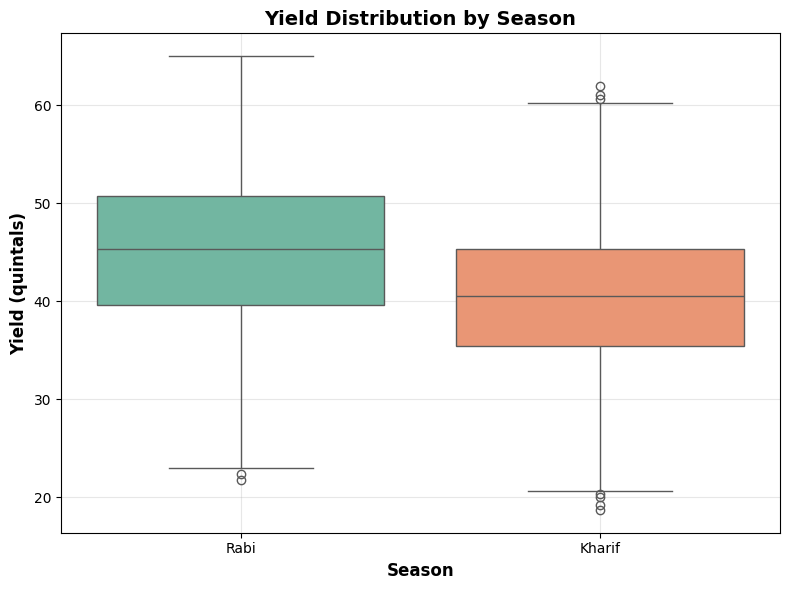

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Season', y='Yield (quintals)', data=df, palette='Set2')
plt.title('Yield Distribution by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12, fontweight='bold')
plt.ylabel('Yield (quintals)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_yield_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

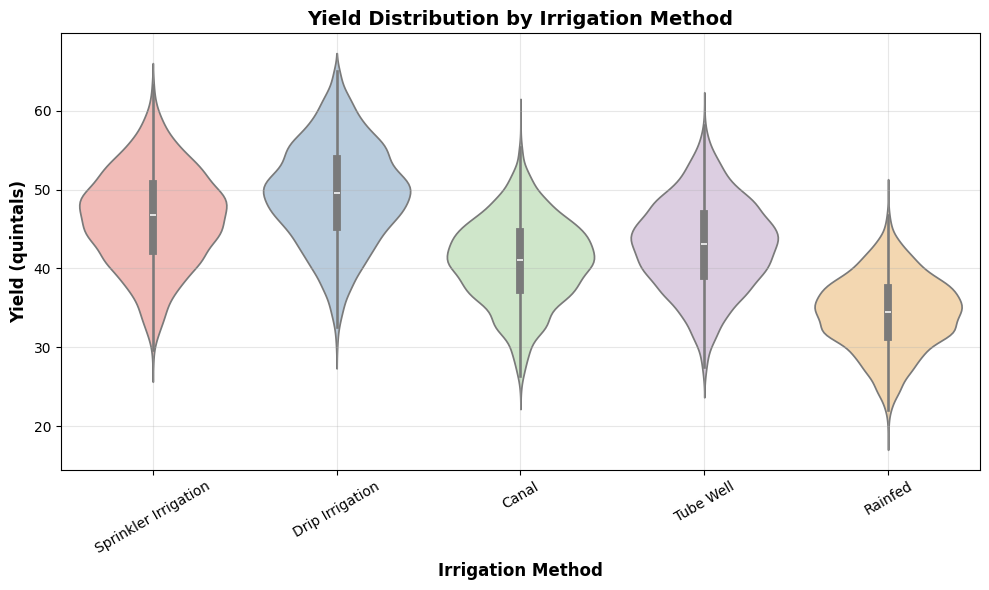

In [10]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Irrigation Method', y='Yield (quintals)', data=df, palette='Pastel1')
plt.title('Yield Distribution by Irrigation Method', fontsize=14, fontweight='bold')
plt.xlabel('Irrigation Method', fontsize=12, fontweight='bold')
plt.ylabel('Yield (quintals)', fontsize=12, fontweight='bold')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_yield_by_irrigation.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

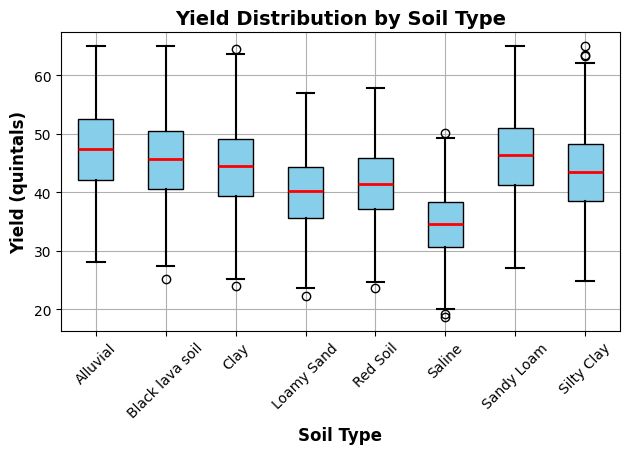

In [11]:
plt.figure(figsize=(12, 6))
df.boxplot(column='Yield (quintals)', by='Soil Type', rot=45,
           patch_artist=True,
           boxprops=dict(facecolor='skyblue', color='black'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='black', linewidth=1.5),
           capprops=dict(color='black', linewidth=1.5))
plt.title('Yield Distribution by Soil Type', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Soil Type', fontsize=12, fontweight='bold')
plt.ylabel('Yield (quintals)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_yield_by_soiltype.png', dpi=150, bbox_inches='tight')
plt.show()


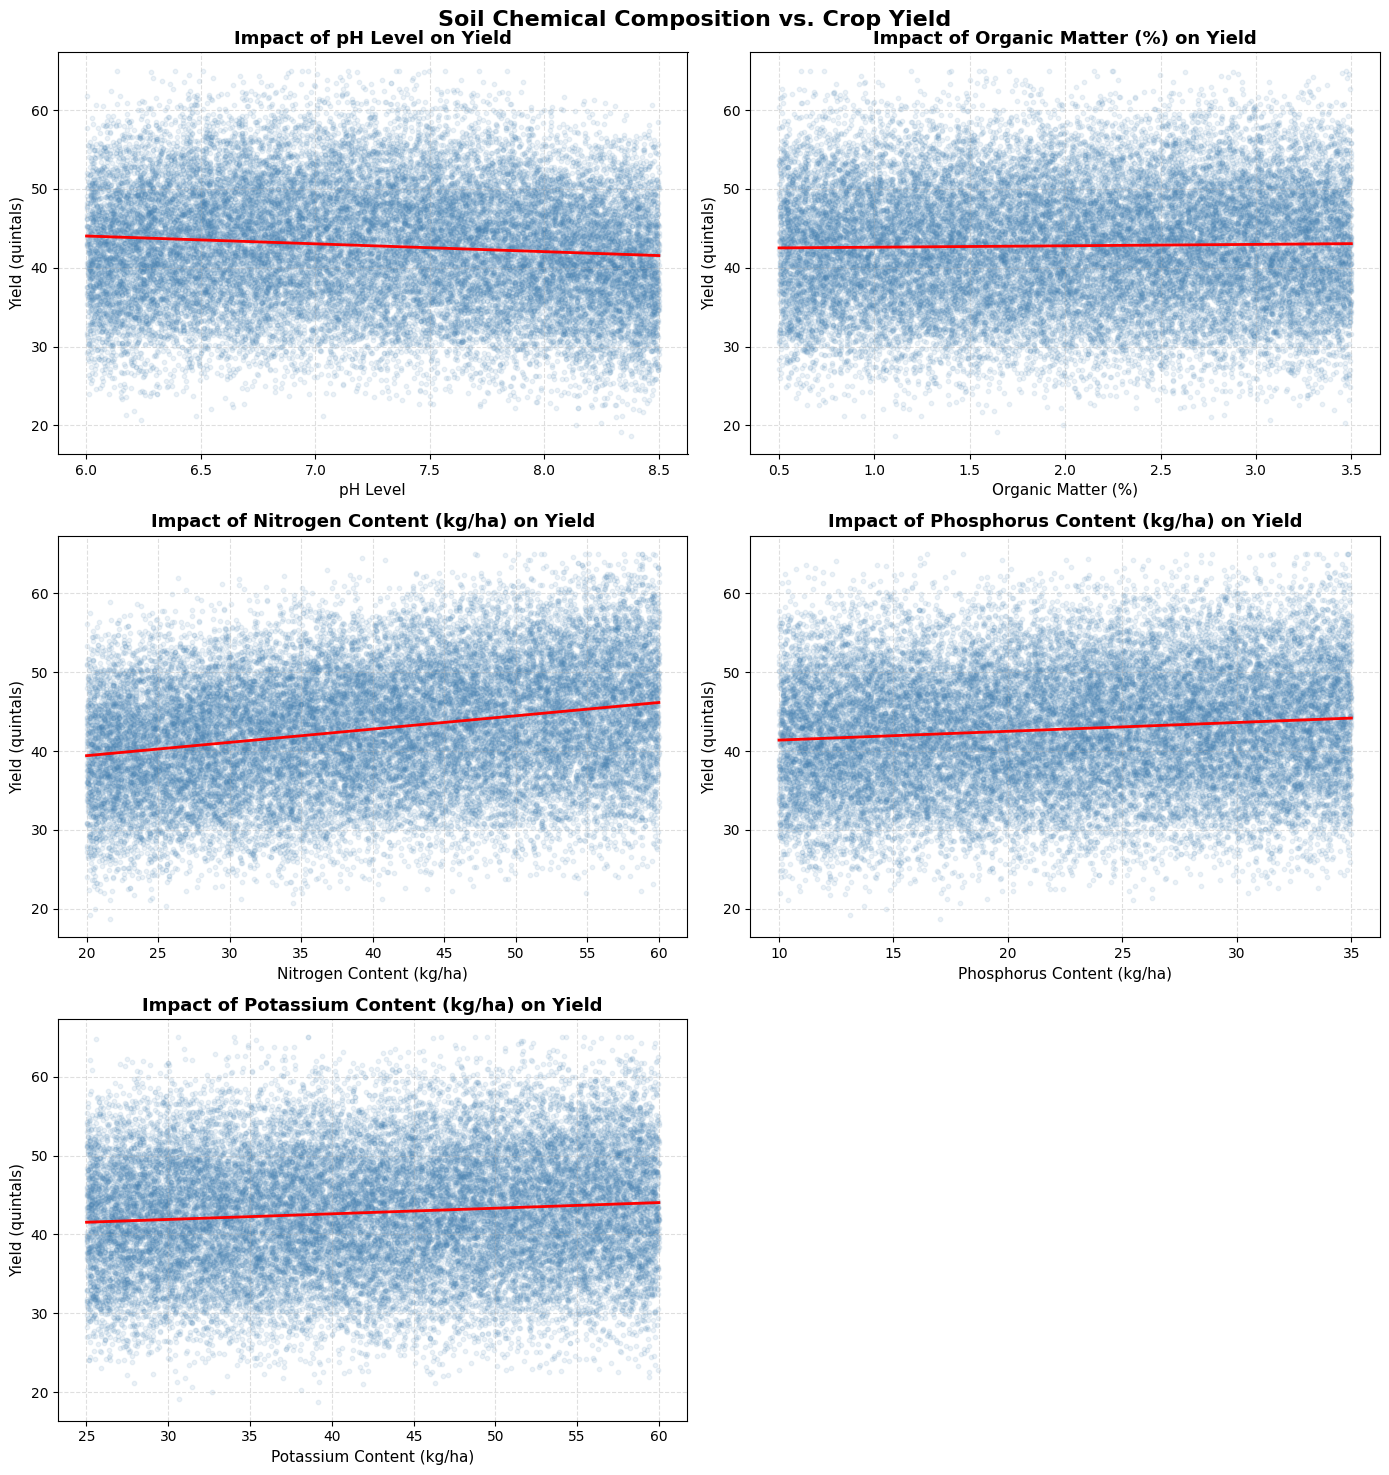

In [12]:
soil_num_features = [
    'pH Level',
    'Organic Matter (%)',
    'Nitrogen Content (kg/ha)',
    'Phosphorus Content (kg/ha)',
    'Potassium Content (kg/ha)'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for i, feature in enumerate(soil_num_features):
    sns.regplot(
        data=df,
        x=feature,
        y='Yield (quintals)',
        ax=axes[i],
        scatter_kws={'alpha': 0.1, 's': 10, 'color': 'steelblue'},
        line_kws={'color': 'red', 'lw': 2}
    )
    axes[i].set_title(f'Impact of {feature} on Yield', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Yield (quintals)', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.4)

fig.delaxes(axes[-1])
fig.suptitle('Soil Chemical Composition vs. Crop Yield', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_soil_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

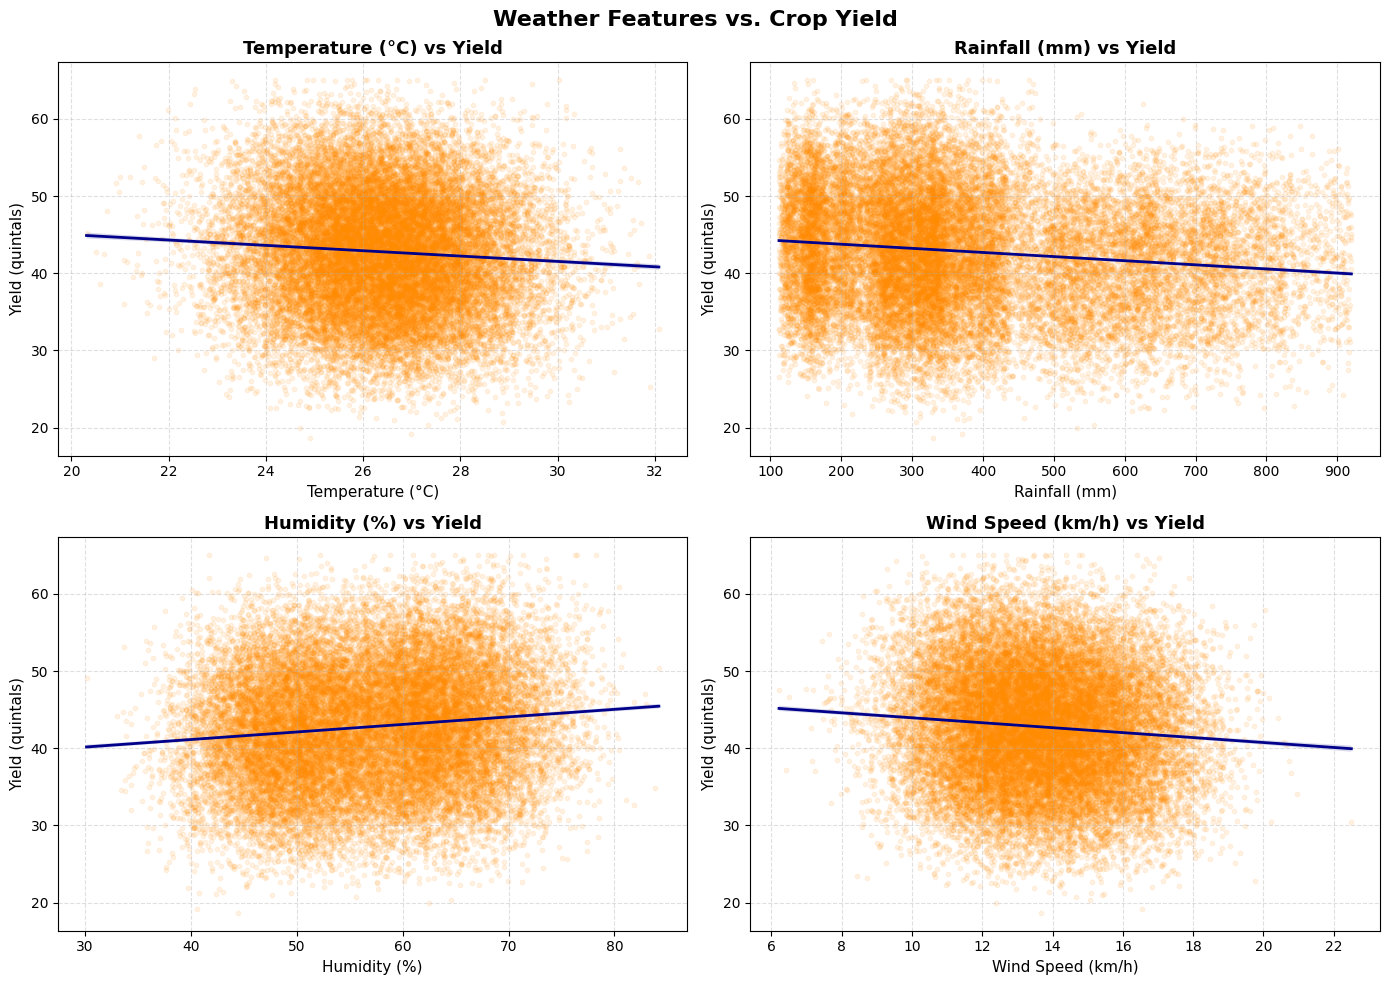

In [13]:
weather_features = ['temp', 'rain', 'humidity', 'wind_speed']
weather_labels = ['Temperature (°C)', 'Rainfall (mm)', 'Humidity (%)', 'Wind Speed (km/h)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feature, label) in enumerate(zip(weather_features, weather_labels)):
    sns.regplot(
        data=df,
        x=feature,
        y='Yield (quintals)',
        ax=axes[i],
        scatter_kws={'alpha': 0.1, 's': 10, 'color': 'darkorange'},
        line_kws={'color': 'darkblue', 'lw': 2}
    )
    axes[i].set_title(f'{label} vs Yield', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(label, fontsize=11)
    axes[i].set_ylabel('Yield (quintals)', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Weather Features vs. Crop Yield', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_weather_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

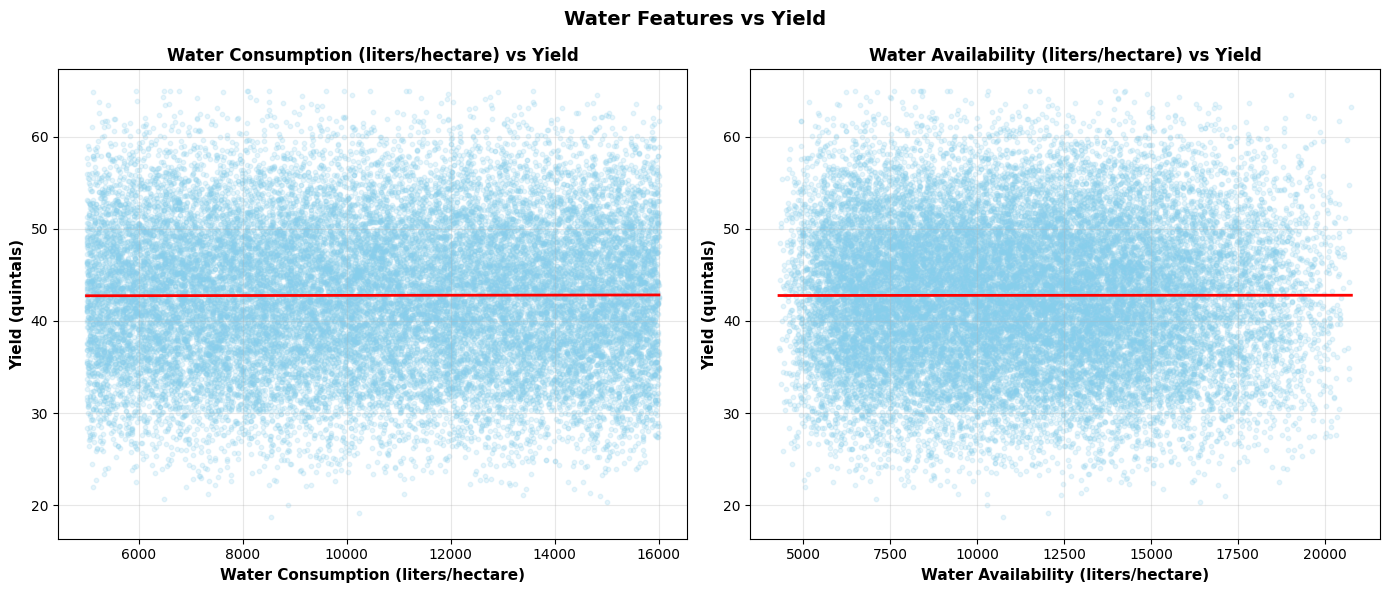

In [14]:
water_features = ['Water Consumption (liters/hectare)', 'Water Availability (liters/hectare)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, feature in enumerate(water_features):
    x = df[feature].values
    y = df['Yield (quintals)'].values
    axes[i].scatter(x, y, alpha=0.2, color='skyblue', s=10)
    m, b = np.polyfit(x, y, 1)
    axes[i].plot(sorted(x), sorted(m * np.array(x) + b), color='red', linewidth=2)
    axes[i].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Yield (quintals)', fontsize=11, fontweight='bold')
    axes[i].set_title(f'{feature} vs Yield', fontsize=12, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.suptitle('Water Features vs Yield', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_water_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

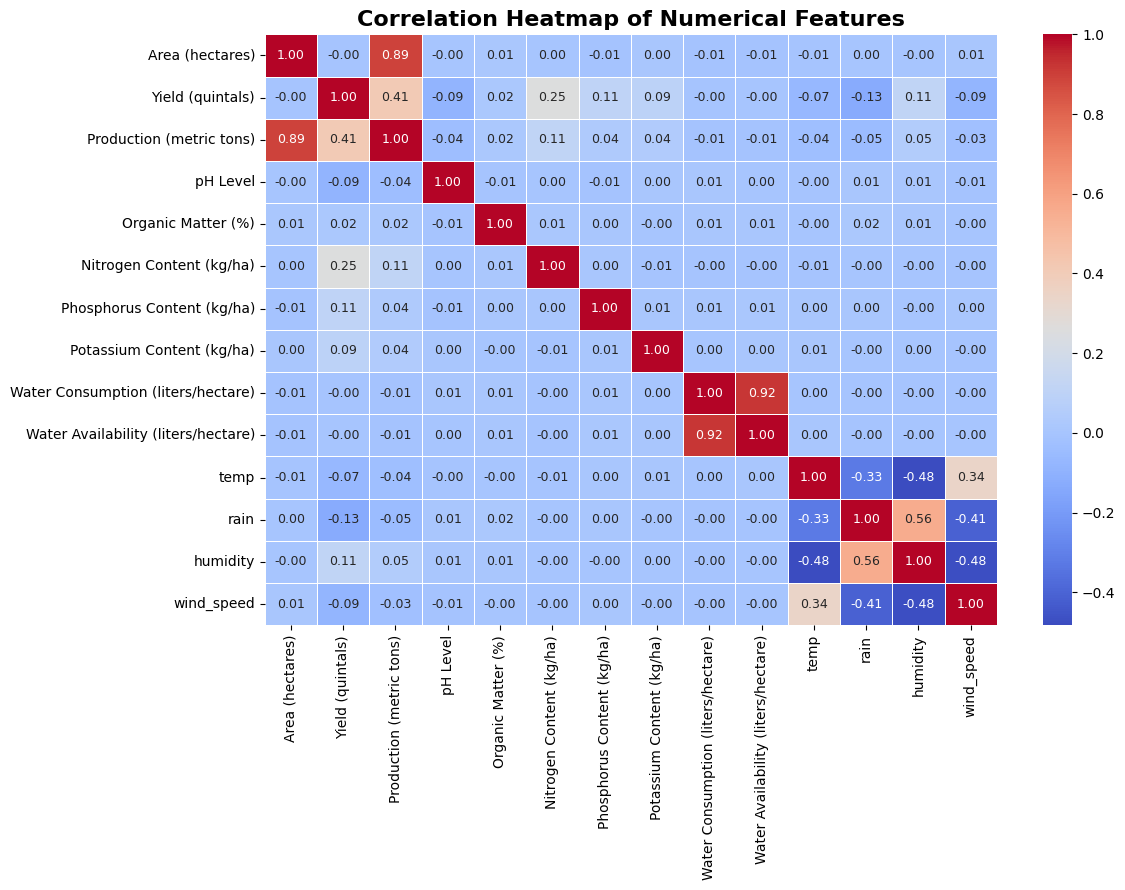


Highly correlated feature pairs (|correlation| >= 0.5):
  Area (hectares)  <-->  Production (metric tons) :  0.89
  Water Consumption (liters/hectare)  <-->  Water Availability (liters/hectare) :  0.92
  rain  <-->  humidity :  0.56


In [15]:
num_cols = df.select_dtypes(include='float64').columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print highly correlated pairs
print("\nHighly correlated feature pairs (|correlation| >= 0.5):")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.5:
            print(f"  {corr.columns[i]}  <-->  {corr.columns[j]} :  {val:.2f}")


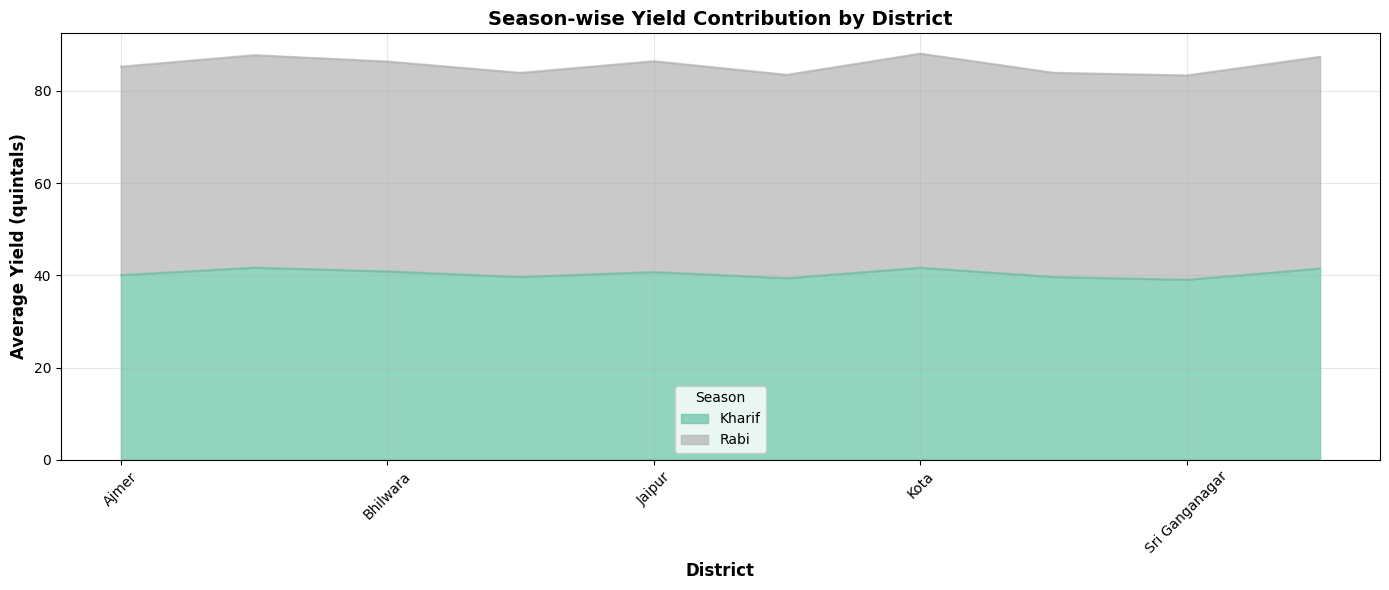

In [16]:
season_district = df.groupby(['District', 'Season'])['Yield (quintals)'].mean().unstack()
season_district.plot(kind='area', stacked=True, figsize=(14, 6), colormap='Set2', alpha=0.7)
plt.xlabel('District', fontsize=12, fontweight='bold')
plt.ylabel('Average Yield (quintals)', fontsize=12, fontweight='bold')
plt.title('Season-wise Yield Contribution by District', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_season_district_area.png', dpi=150, bbox_inches='tight')
plt.show()

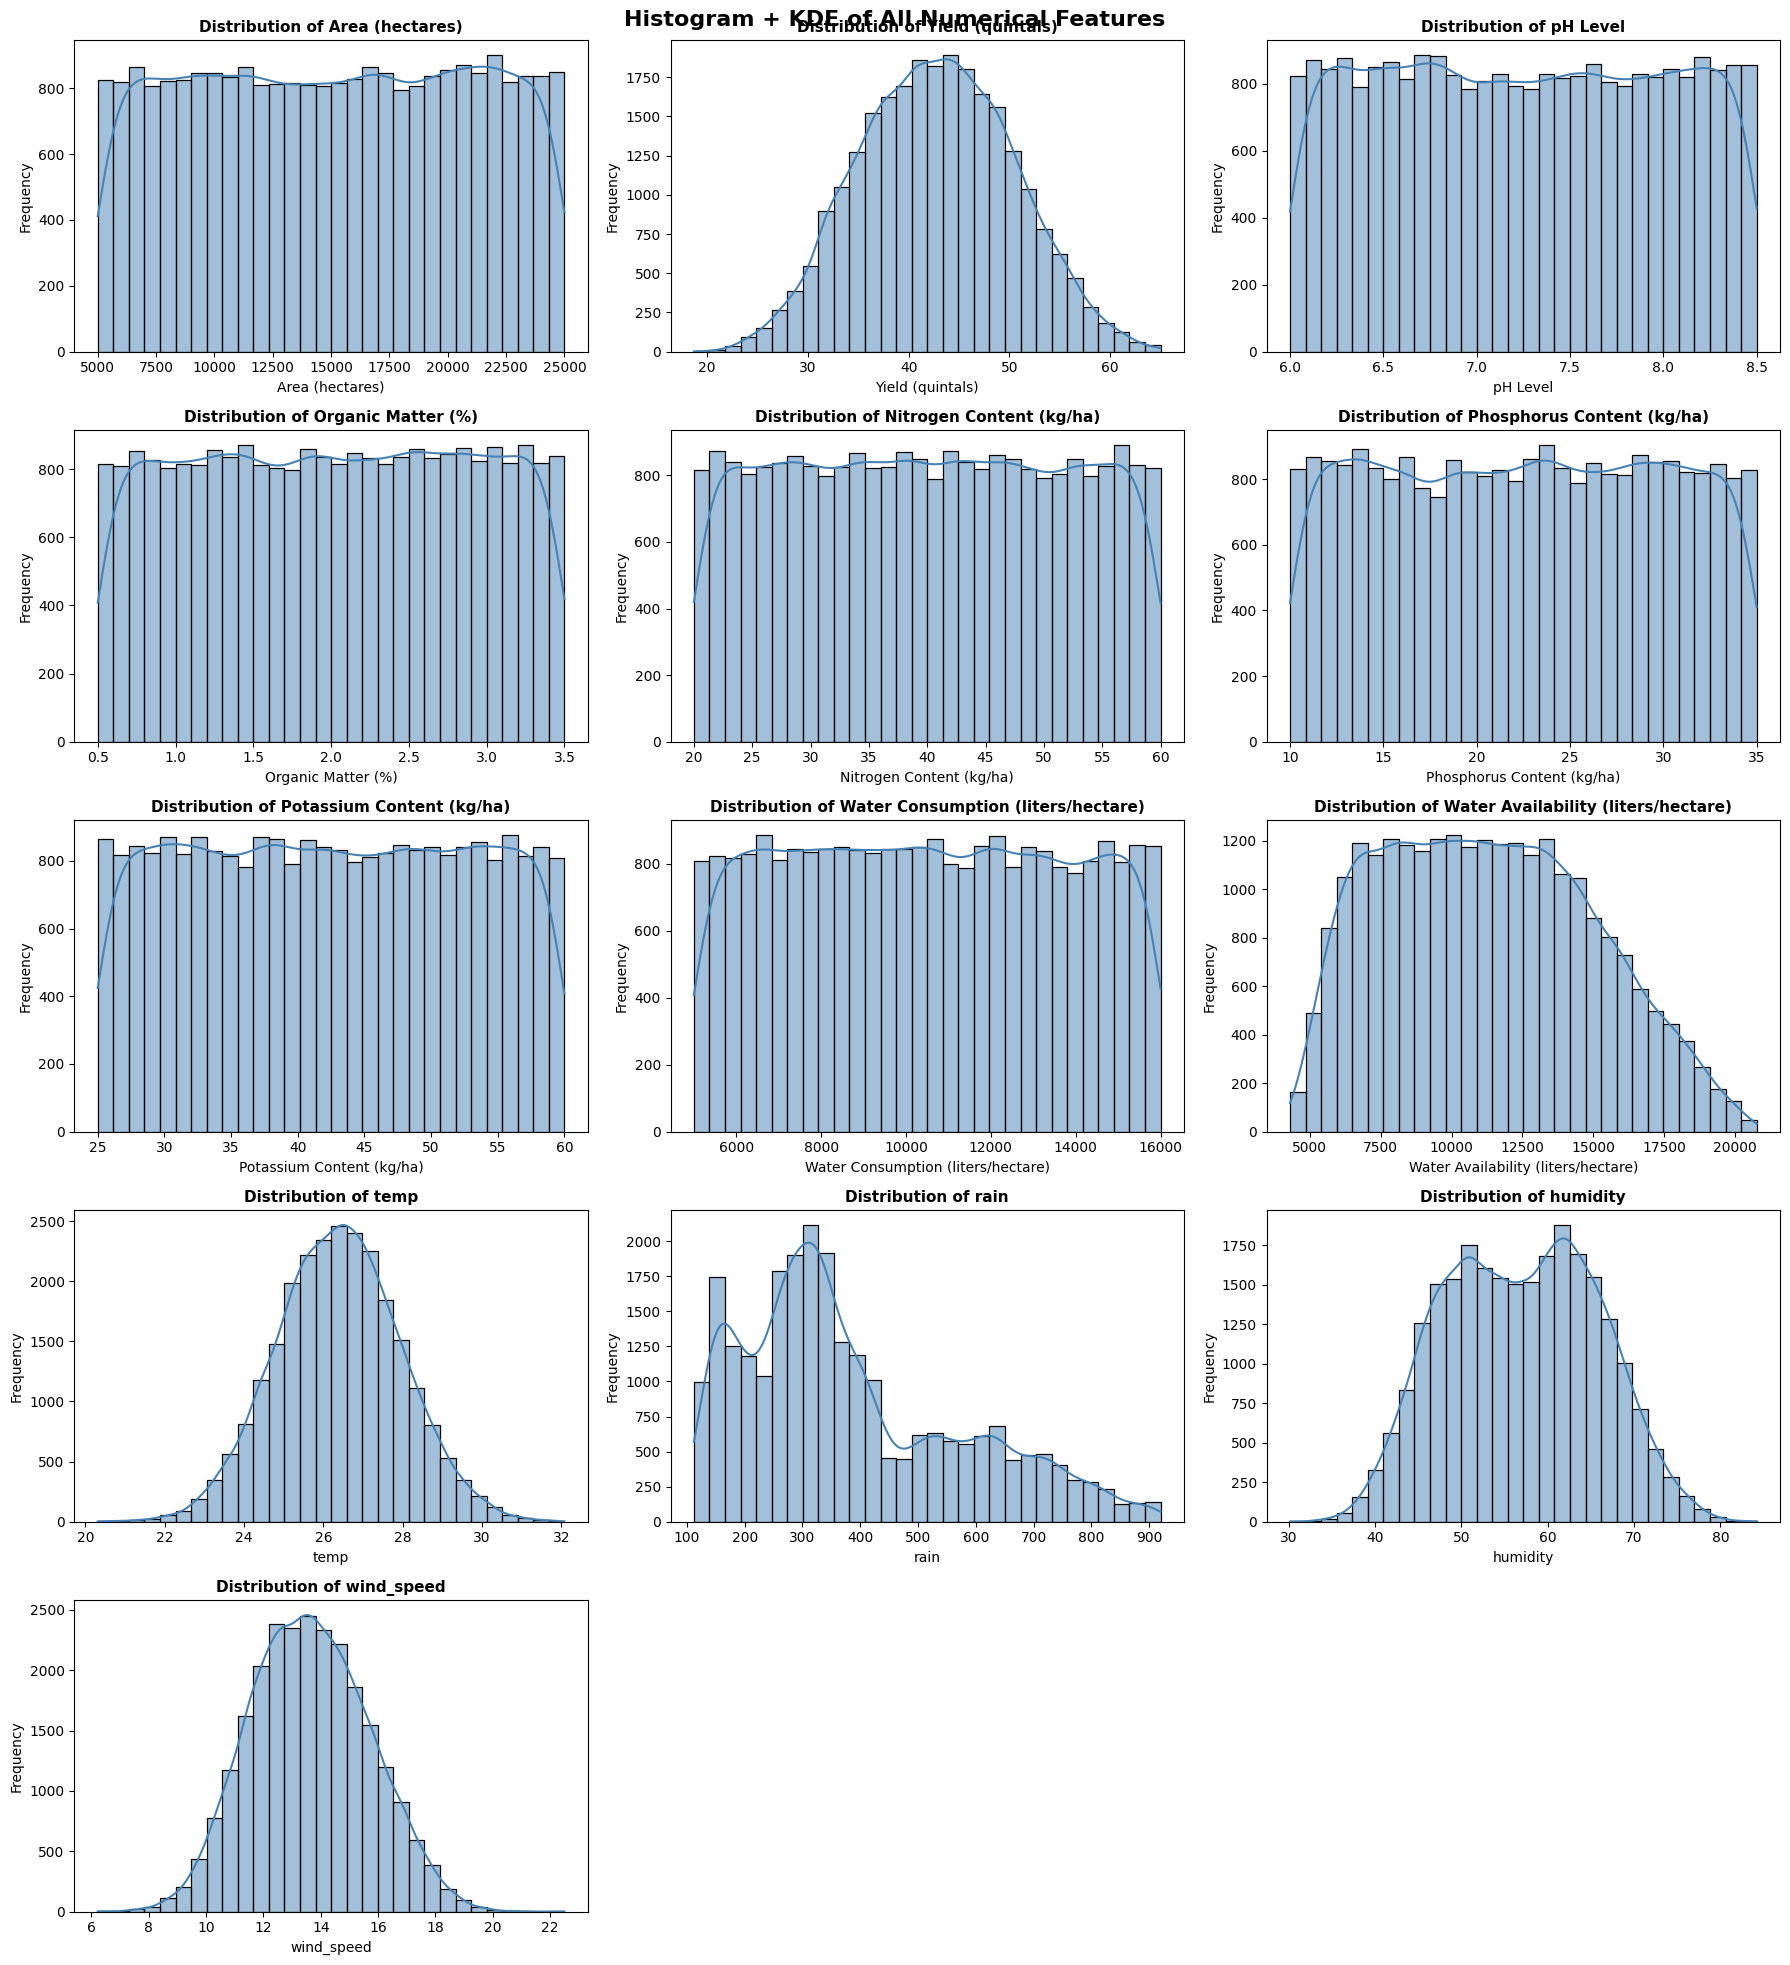

In [17]:
num_features_all = [
    'Area (hectares)', 'Yield (quintals)',
    'pH Level', 'Organic Matter (%)',
    'Nitrogen Content (kg/ha)', 'Phosphorus Content (kg/ha)',
    'Potassium Content (kg/ha)',
    'Water Consumption (liters/hectare)', 'Water Availability (liters/hectare)',
    'temp', 'rain', 'humidity', 'wind_speed'
]

n_cols = 3
n_rows = (len(num_features_all) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features_all):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histogram + KDE of All Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_all_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
cat_cols = ['District', 'Season', 'Soil Type', 'Irrigation Method']
print("\nCategorical Feature Value Counts:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Categorical Feature Value Counts:

District:
District
Jodhpur           2546
Nagaur            2542
Bhilwara          2514
Kota              2509
Ajmer             2503
Hanumangarh       2502
Udaipur           2501
Alwar             2498
Sri Ganganagar    2450
Jaipur            2435
Name: count, dtype: int64

Season:
Season
Kharif    12508
Rabi      12492
Name: count, dtype: int64

Soil Type:
Soil Type
Loamy Sand         3176
Clay               3152
Red Soil           3143
Black lava soil    3127
Silty Clay         3126
Saline             3108
Sandy Loam         3108
Alluvial           3060
Name: count, dtype: int64

Irrigation Method:
Irrigation Method
Rainfed                 5056
Sprinkler Irrigation    5052
Drip Irrigation         5012
Tube Well               4980
Canal                   4900
Name: count, dtype: int64


In [19]:
print("\n" + "="*60)
print("EDA SUMMARY")
print("="*60)
print(f"Total Rows       : {len(df):,}")
print(f"Total Features   : {df.shape[1]}")
print(f"Yield Range      : {df['Yield (quintals)'].min():.2f} - {df['Yield (quintals)'].max():.2f} quintals")
print(f"Mean Yield       : {df['Yield (quintals)'].mean():.2f} quintals")
print(f"Std Dev Yield    : {df['Yield (quintals)'].std():.2f} quintals")
print(f"Districts        : {df['District'].nunique()}")
print(f"Seasons          : {df['Season'].nunique()} ({', '.join(df['Season'].unique())})")
print(f"Soil Types       : {df['Soil Type'].nunique()}")
print(f"Irrigation Types : {df['Irrigation Method'].nunique()}")
print("="*60)
print("\nTop correlations with Yield:")
yield_corr = corr['Yield (quintals)'].drop('Yield (quintals)').abs().sort_values(ascending=False)
print(yield_corr.head(8))


EDA SUMMARY
Total Rows       : 25,000
Total Features   : 19
Yield Range      : 18.68 - 65.00 quintals
Mean Yield       : 42.78 quintals
Std Dev Yield    : 7.64 quintals
Districts        : 10
Seasons          : 2 (Rabi, Kharif)
Soil Types       : 8
Irrigation Types : 5

Top correlations with Yield:
Production (metric tons)      0.414032
Nitrogen Content (kg/ha)      0.254822
rain                          0.132375
humidity                      0.111984
Phosphorus Content (kg/ha)    0.105674
pH Level                      0.094408
Potassium Content (kg/ha)     0.094313
wind_speed                    0.086718
Name: Yield (quintals), dtype: float64
